In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
from scipy.stats import stats
from scipy.optimize import minimize

# Laboratorio # 2

## Regresión lineal

**1)** Crear un data frame de pandas con los siguientes datos:

|Entrenamiento|Y| X_1 |
|-|-|-|
|0|0|0|
|1|1|1|
|2|2|2|
|3|3|3|
|4|4|4|
|m|5|5|

In [2]:
dataDict = {
    'X' : [0,1,2,3,4,5],
    'Y' : [0,1,2,3,4,5]
}
df = pd.DataFrame(dataDict)
df

,X,Y
0,0,0
1,1,1
2,2,2
3,3,3
4,4,4
5,5,5


**2)** Crear una función para calcular la función de coste.

In [3]:
def cost(m,b,X,Y):
    '''
    b: intercepto
    m: pendiente
    X: variable independiente
    Y: variable dependiente
    '''

    if len(X) == len(Y):
        n = len(X)
        J = 0
        for i in range(n):
            J += (b + m*X[i] - Y[i])**2
        return J/(2*n)

**3)** Asumiendo que  $\theta_0 = 0$ , represente gráficamente la función de costo para diferentes valores de  $\theta_1$ . Determine el valor mínimo de la función de costo y, con este valor, grafique la ecuación de regresión obtenida sobre los datos del dataframe que ha construido.

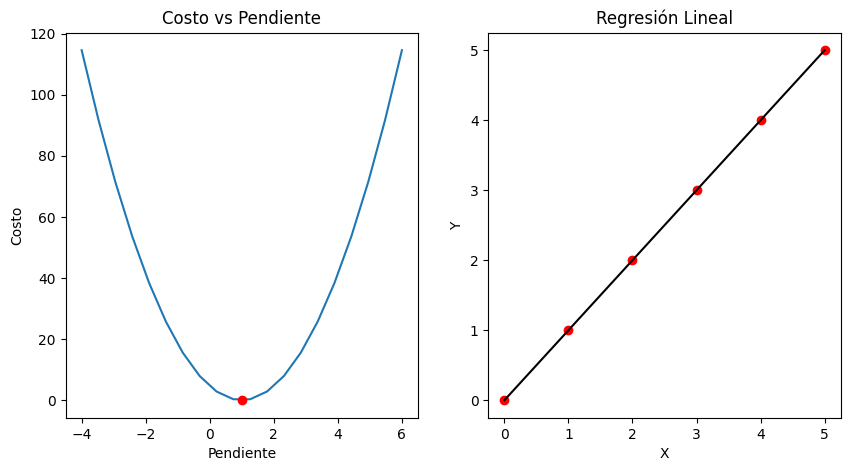

In [4]:
b = 0
m = np.linspace(-4,6,20)
J = cost(m,b,df.X,df.Y)

a = minimize(cost,0,args=(b,df.X,df.Y))
mMin = a.x # encontramos el valor mínimo para la pendiente.

plt.figure(figsize=(10,5))
plt.subplot(121)
plt.title('Costo vs Pendiente')
plt.xlabel('Pendiente')
plt.ylabel('Costo')
plt.plot(m,J)
plt.plot(mMin,cost(mMin,b,df.X,df.Y),'ro')

plt.subplot(122)
plt.title('Regresión Lineal')
plt.xlabel('X')
plt.ylabel('Y')
plt.plot(df.X,df.Y,'ro')
plt.plot(df.X,mMin*df.X+b,'k-')


**4)** Suponiendo ahora que los datos de entrenamiento viene dados de la siguiente manera:

|Entrenamiento|Y| X_1 |
|-|-|-|
|0|0|0|
|1|1|1|
|2|2|2|
|3|3|3|
|4|4|4|
|m|5|5|

Encontrar la función de coste para diferentes valores de $\theta_0$, $\theta_1$.
Para ello puede emplear los metodos `surface` y `contour` dentro de la libreria de `matplotlib`.  Construya primero, con los valores de $\theta_0$, $\theta_1 $ definidos un `np.meshgrid` y evalue  para cada punto $\theta_0$, $\theta_1$ la función de coste.

Para el gráfico 3D puede emplear algo similar a las siguientes lineas de código

```
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot_surface(t0, t1, J )
ax.contour(t0, t1, J, 200,   linestyles="solid")
ax.set_xlabel("$\\theta_0$")
ax.set_ylabel("$\\theta_1$")
plt.show()
```


En los casos anteriores la solución solo involucra 1 y 2 parámetros para la representación de la función de coste en  2D y 3D respectivamente. Cuando se tienen más parametros a optmizar, no podemos tener una representacion gráfica, análoga a los casos anteriores. Notese además que los datos anteriores no tiene ningún ruido y solo se esta realizados  de esta manera, por motivos didácticos.

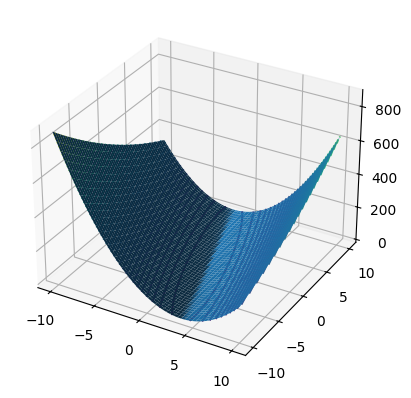

In [5]:
ms = np.linspace(-10,10,100)
bs = np.linspace(-10,10,100)
M, B = np.meshgrid(ms, bs)
J = cost(M,B,df.X,df.Y)

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

ax.plot_surface(M,B,J)
ax.contour(M,B,J, 50,   linestyles="solid")
plt.show()

In [6]:
# una mejor forma de visualizar la función de costo es con plotly
fig = go.Figure(data=[go.Surface(z=J, x=B, y=M)])

fig.update_layout(title='Cost Function',
                  scene = dict(
                      xaxis_title='intercept (b)',
                      yaxis_title='slope (m)',
                      zaxis_title='J(m,b)'),
                  autosize=False,
                  width=500, height=500,
                  margin=dict(l=65, r=50, b=65, t=90))

fig.show()

**5)** Encontrar la expresión teórica para la función de coste en el caso 1D y 2D.

### Caso 1D  

En una dimensión tenemos que $\theta_0 = 0$, de manera que la función de coste toma la forma:


$$J(\theta_1) = \frac{1}{2m}\sum_{i=0}^m[\theta_1 x_i - y_i]^2$$


Si expadimos y agrupamos encontramos que la expresión que representa la función de coste en el caso unidimensional es un polinomio cuya variable es $\theta_1$:

$$J(\theta_1) = \left( \frac{\sum x_i^2}{2m} \right){\theta_1}^2 - \left( \frac{\sum x_iy_i}{m} \right)\theta_1 + \frac{\sum y_i^2}{2m}$$


#### Caso 2D

En dos dimensiones partimos de la siguiente expresión para la función de coste:


$$J(\theta_0, \theta_1) = \frac{1}{2m}\sum_{i=0}^m[(\theta_0 + \theta_1 x_i) - y_i]^2$$


expandiendo y agrupando sobre las variables encontramos que la función de coste está representada por el siguiente polinomio de dos variables:


$$J(\theta_0,\theta_1) = \left(\frac{1}{2}\right){\theta_0}^2 - \left(\frac{\sum y_i}{m}\right)\theta_0 + \left(\frac{\sum x_i^2}{2m}\right){\theta_1}^2 - \left(\frac{\sum x_iy_i}{m}\right)\theta_1 + \left(\frac{\sum x_i}{m}\right)\theta_0\theta_1 + \frac{\sum y_i^2}{2m}$$

Que en términos del caso unidimensional puede verse así:

$$J(\theta_0,\theta_1) = J(\theta_1) + \left(\frac{1}{2}\right){\theta_0}^2 - \left(\frac{\sum y_i}{m}\right)\theta_0 + \left(\frac{\sum x_i}{m}\right)\theta_0\theta_1$$

## Gradiente descendente

**6)** Construya un algoritmo en el que emplee el gradiente descente para determinar el minimo de una función, determine el mínimo con un error epsilon de  $10^{-4}$, pruebe su algoritmo para  
    $f(x)= (x-4)^2$ y al menos 3 valores de $\alpha$

In [7]:
def GradDescent(f,w=0,alpha=0.1):

    '''
    Función de gradiente descendente para encontrar
    el mínimo de una función
    f: función a minimizar
    w: valor inicial
    alpha: tasa de aprendizaje
    '''

    import numdifftools as nd

    Df = nd.Derivative(f)  # Derivada de la función
    c = True  # condición de continuidad
    while c == True:
        wNew = w - alpha*Df(w)
        if abs(Df(wNew)) < 1e-4:
            c = False
        else:
            w = wNew
    return wNew

In [8]:
# puesta a prueba del algoritmo para diferentes valoes de alpha
alpha = [0.1, 0.01, 0.001]
for a in alpha:
    yMin = GradDescent(lambda x: (x - 4)**2, alpha=a)
    print(f'alpha: {a}, yMin: {yMin:.5f}')

alpha: 0.1, yMin: 3.99995
alpha: 0.01, yMin: 3.99995
alpha: 0.001, yMin: 3.99995


El algoritmo tarda más para valores de $\alpha$ más pequeños, mientras que un valor muy alto puede conducir a un valor erroneo del mínimo.

**7)** A través del metodo del gradiente descendente encontrar el mínimo de la siguiente función:


\begin{equation}
F(x,y) = \sin \left( \frac{1}{2}x^2-\frac{1}{4}y^2 +3\right) \cos (2x+1-e^y)
\end{equation}

  -  Para ello realice una gráfica de la función en 3D, y un mapa de contorno de la función.
  - Determine el valor mínimo de la función con el metodo del gradiente descendente.


In [9]:
def F(w):
    x, y = w
    return np.sin(0.5*x**2 - 0.25*y**2 + 3)*np.cos(2*x + 1 - np.exp(y))

y = np.linspace(0, 3, 500)
x = np.linspace(0, 3, 500)
X, Y = np.meshgrid(x, y)
Z = F([X, Y])
fig = go.Figure(data=[go.Surface(z=Z, x=X, y=Y)])
fig.update_layout(title='Cost Function',
                  scene = dict(
                      xaxis_title='X',
                      yaxis_title='Y',
                      zaxis_title='F(X,Y)'),
                  autosize=False,
                  width=600, height=600,
                  margin=dict(l=65, r=50, b=65, t=90))
fig.show()


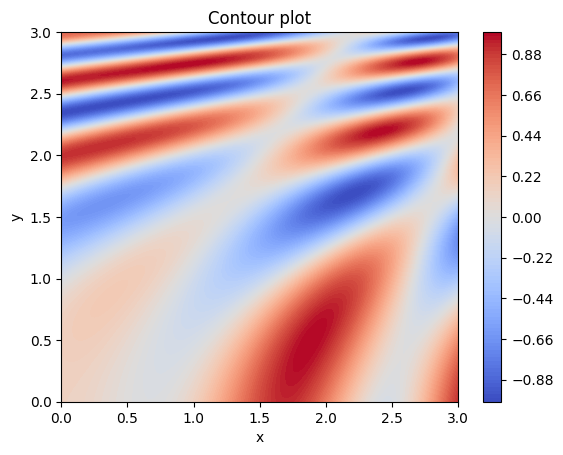

In [10]:
plt.contourf(X,Y,Z, 100, linestyles='solid', cmap='coolwarm')
plt.title('Contour plot')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()
plt.show()

En las figuras anteriores vemos la superficie en 3D y el mapa de contorno de la función.

Generalizamos ahora el método del gradiente descendente para funciones de dos variables, seleccionando de manera aleatoria un punto sobre el intervalo deseado, de manera que la función encontrará un mínimo específico para cada punto aleatorio generado sobre el intervalo del plano.

In [17]:
# gradiente descendente para funciones de dos dimensiones
def GradDescent2(f,interval,alpha=0.01,tol=1e-6):
    '''
    Función de gradiente descendente para encontrar
    el mínimo de una función 2D
    f: función a minimizar
    alpha: tasa de aprendizaje
    '''

    import numdifftools as nd
    
    Gf = nd.Gradient(f)  # Derivada de la función
    x = np.random.uniform(interval[0],interval[1])
    y = np.random.uniform(interval[0],interval[1])
    w = np.array([x,y])  # valor inicial
    c = True  # condición de continuidad
    while c == True:
        wNew = w - alpha*Gf(w)
        grad = Gf(wNew)
        if np.linalg.norm(grad) < tol:
            c = False
        else:
            w = wNew

    return wNew,[x,y]

Ponemos a prueba la función en el intervalo considerado anteriormente, se muestran las coordenadas del punto aleatorio inicial (azul) y las del punto en el mínimo (rojo) encontrado por medio del algoritmo del gradiente descendente. Se muestra también una flecha que esclarece el cambio del punto inicial en comparación con los parámetros del mínimo encontrado.


      * Parámetros del punto rand: x = 0.697, y = 0.599, z = -0.009
      * Parámetros del mínimo encontrado: x = 2.202, y = 1.687, z = -1.000
      


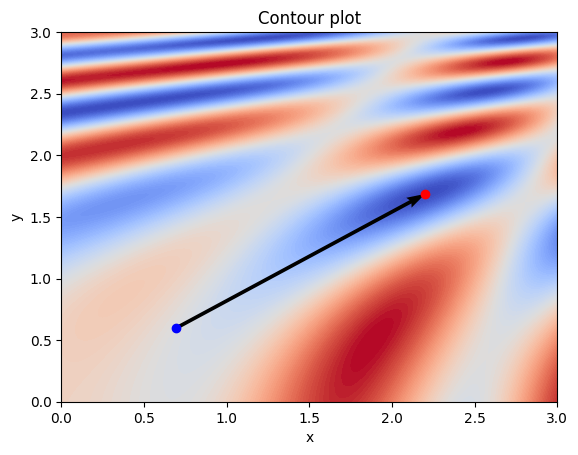

In [43]:
min, rand = GradDescent2(F,[0,3])
print(f'''
      * Parámetros del punto rand: x = {rand[0]:.3f}, y = {rand[1]:.3f}, z = {F(rand):.3f}
      * Parámetros del mínimo encontrado: x = {min[0]:.3f}, y = {min[1]:.3f}, z = {F(min):.3f}
      ''')

plt.contourf(X,Y,Z, 100, linestyles='solid', cmap='coolwarm')
plt.plot(min[0],min[1],'ro')
plt.plot(rand[0],rand[1],'bo')
plt.quiver(rand[0], rand[1], min[0]-rand[0], min[1]-rand[1], angles='xy', scale_units='xy',scale=1)
plt.title('Contour plot')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

**8)** Construya un algoritmo que permita determinar una regresión lineal con base en las herramientas desarrolladas en los apartados anteriores y en los datos de `x` y `y`

Se define la función de costo para el conjunto de datos, y se aplica la rutina de gradiente descendente sobre esta. El tiempo de ejecución es poco más de un minuto y el resultado es tal como se muestra en la figura siguiente.

In [66]:
x = np.linspace(0, 1, 100)
y = 0.2 + 0.2*x + 0.02*np.random.random(100)

def Fcost(w):
    th0, th1 = w
    n = len(x)
    J = 0
    for i in range(n):
        J += (th1 + th0*x[i] - y[i])**2
    return J/(2*n)

# gradiente descendente aplicado sobre la función de costo
thetas, _ = GradDescent2(Fcost,[0,1])


    * Pendiente estimada:  m = 0.200
    * Intercepto estimado: b = 0.210



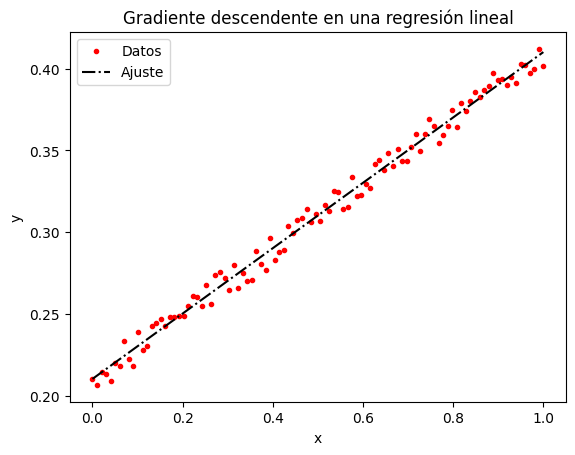

In [77]:
print(f'''
    * Pendiente estimada:  m = {thetas[0]:.3f}
    * Intercepto estimado: b = {thetas[1]:.3f}
'''
)
plt.plot(x,y,'r.',label='Datos')
plt.plot(x,thetas[0]*x + thetas[1],'k-.',label='Ajuste')
plt.title('Gradiente descendente en una regresión lineal')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

**9)** Compare su resultado empleando la libreria linearRegression() de sklearn.

In [71]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x.reshape(-1,1),y)

LinearRegression()


    Con las herramientas construídas
    * Pendiente estimada:  m = 0.200
    * Intercepto estimado: b = 0.210


    Con sklearn
    * Pendiente estimada:  m = 0.200
    * Intercepto estimado: b = 0.210



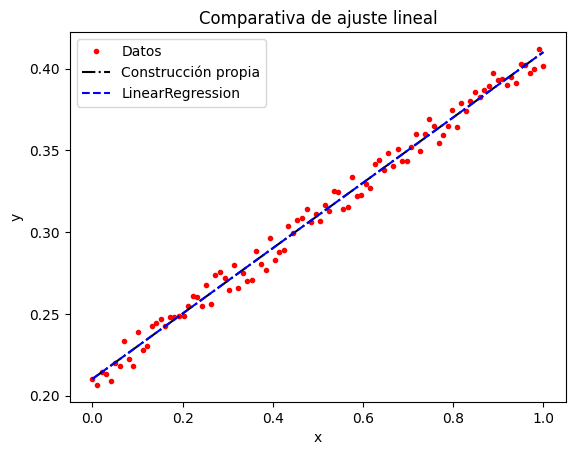

In [85]:
m_ = model.coef_[0]
b_ = model.intercept_

print(f'''
    Con las herramientas construídas
    * Pendiente estimada:  m = {thetas[0]:.3f}
    * Intercepto estimado: b = {thetas[1]:.3f}

    ================================

    Con sklearn
    * Pendiente estimada:  m = {m_:.3f}
    * Intercepto estimado: b = {b_:.3f}
'''
)
plt.plot(x,y,'r.',label='Datos')
plt.plot(x,thetas[0]*x + thetas[1],'k-.',label='Construcción propia')
plt.plot(x,m_*x + b_,'b--',label='LinearRegression')
plt.title('Comparativa de ajuste lineal')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

No se percibe una diferencia significativa en los resultados de ambos metodos, sin embargo el tiempo de ejecución mediante el uso de sklearn es despreciable en comparación con el tiempo requerido para el ajuste por medio de las herramientas construidas.

### *Juan José Pérez Avendaño*